In [1]:
import numpy as np
import matplotlib.pyplot as plt
from distmesh import distmesh2D, dcircle, ddiff, huniform
from scipy import sparse
from scipy.sparse.linalg import spsolve

plt.rcParams.update({'font.size': 14})

count =  200 displacement =  0.01262160627862737
count =  400 displacement =  0.006141102149780002


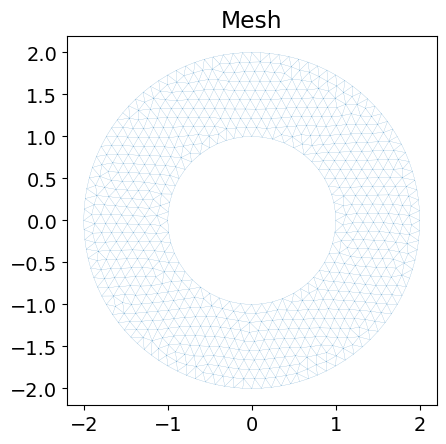

Npts = 781, Ntri = 1404


In [9]:
# distance func in domain
def fd(p):
    return ddiff(dcircle(p, 0, 0, 2), dcircle(p, 0, 0, 1))


theta_fix = np.linspace(0, 2*np.pi, 12, endpoint=False)
pfix_inner = np.c_[np.cos(theta_fix), np.sin(theta_fix)]
pfix_outer = np.c_[2*np.cos(theta_fix), 2*np.sin(theta_fix)]
pfix = np.vstack([pfix_inner, pfix_outer])

h0 = 0.12
bbox = [-2, 2, -2, 2]

pts, tri = distmesh2D(fd, huniform, h0, bbox, pfix)

plt.title('Mesh')
plt.show()

Npts = pts.shape[0]
Ntri = tri.shape[0]
print(f'Npts = {Npts}, Ntri = {Ntri}')

Boundary nodes: 158, Interior nodes: 623


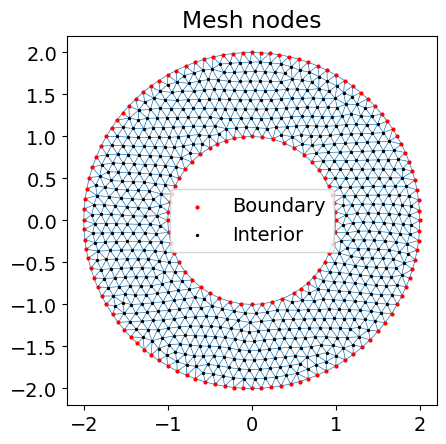

In [3]:
edges = np.zeros((Ntri*3, 2), dtype=int)
for j in range(Ntri):
    t = tri[j, :]
    edges[3*j,   :] = np.sort([t[0], t[1]])
    edges[3*j+1, :] = np.sort([t[0], t[2]])
    edges[3*j+2, :] = np.sort([t[1], t[2]])


unique_edges, counts = np.unique(edges, axis=0, return_counts=True)
Bdry = np.unique(unique_edges[counts == 1, :].ravel())
Interior = np.setdiff1d(np.unique(unique_edges.ravel()), Bdry)

print(f'Boundary nodes: {len(Bdry)}, Interior nodes: {len(Interior)}')

plt.figure()
plt.triplot(pts[:, 0], pts[:, 1], tri, linewidth=0.5)
plt.scatter(pts[Bdry, 0], pts[Bdry, 1], s=4, c='red',label='Boundary')
plt.scatter(pts[Interior, 0], pts[Interior, 1],s=2,c='black', label='Interior')
plt.gca().set_aspect('equal')
plt.legend()
plt.title('Mesh nodes')
plt.show()

In [4]:
def stima3(vertices):
    PhiGrad = np.linalg.solve(
        np.array([[1,1,1],
                  [vertices[0,0], vertices[1,0], vertices[2,0]],
                  [vertices[0,1], vertices[1,1], vertices[2,1]]]),
        np.array([[0, 0],[1, 0],[0, 1]]))
    area = 0.5*abs(np.linalg.det(np.array([[vertices[1,0]-vertices[0,0], vertices[2,0]-vertices[0,0]],
                                           [vertices[1,1]-vertices[0,1], vertices[2,1]-vertices[0,1]]])))
    return area*(PhiGrad @ PhiGrad.T)


# assemble matrices
A = sparse.lil_matrix((Npts, Npts))
B = sparse.lil_matrix((Npts, Npts))
b_f = np.zeros(Npts)

for j in range(Ntri):
    idx   = tri[j, :]
    verts = pts[idx, :]

    det_val = np.linalg.det(np.array([[1,1,1],
                  [verts[0,0], verts[1,0], verts[2,0]],
                  [verts[0,1], verts[1,1], verts[2,1]]]))

    A_loc = stima3(verts)
    for a in range(3):
        for b_ in range(3):
            A[idx[a], idx[b_]] += A_loc[a, b_]

    B_loc = det_val * np.array([[2,1,1],[1,2,1],[1,1,2]])/24.0
    for a in range(3):
        for b_ in range(3):
            B[idx[a], idx[b_]] += B_loc[a, b_]

    b_f[idx] += det_val/6.0

A = A.tocsr()
B = B.tocsr()
print('A, B, b_f assembled.')

A, B, b_f assembled.


In [5]:
dt = 0.01
T = 1.2
N = round(T/dt)

# IC + BCs
r_nodes = np.sqrt(pts[:,0]**2 + pts[:,1]**2)
phi_nodes = np.arctan2(pts[:,1], pts[:,0])
U_cur = r_nodes + np.cos(phi_nodes)
U_cur[Bdry] = 0.0

LHS = (dt/2.0)*A + B # matrix on LHS (Delta t/2 A +B)
RHS_mat = -(dt/2.0)*A + B # matrix on RHS (-Delta t/2 A +B)

LHS_int = LHS[np.ix_(Interior, Interior)]
t_save = {}

for n in range(N):
    t_new = round((n+1)*dt,10)

    rhs = RHS_mat.dot(U_cur) + dt*b_f
    rhs[Bdry] = 0.0 #boundary

    u_new = np.zeros(Npts)
    u_new[Interior] = spsolve(LHS_int, rhs[Interior])
    U_cur = u_new

    if abs(t_new - 0.1) < 1e-9:
        t_save[0.1] = u_new.copy()
    if abs(t_new - 1.0) < 1e-9:
        t_save[1.0] = u_new.copy()

print('Time-stepping complete.')

Time-stepping complete.


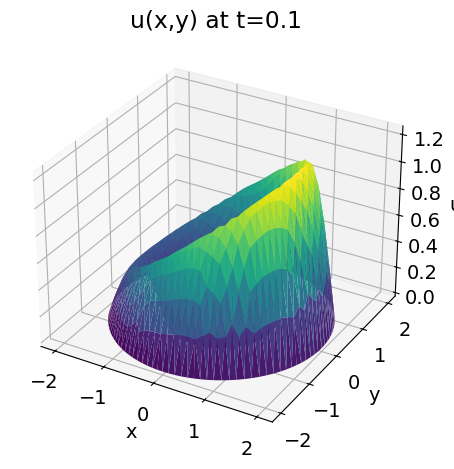

In [13]:
#fig 1: sol at t=0.1
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_trisurf(pts[:,0], pts[:,1], t_save[0.1],triangles=tri, cmap='viridis', linewidth=0.1)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('u')
ax.set_title('u(x,y) at t=0.1')
plt.tight_layout()
plt.show()

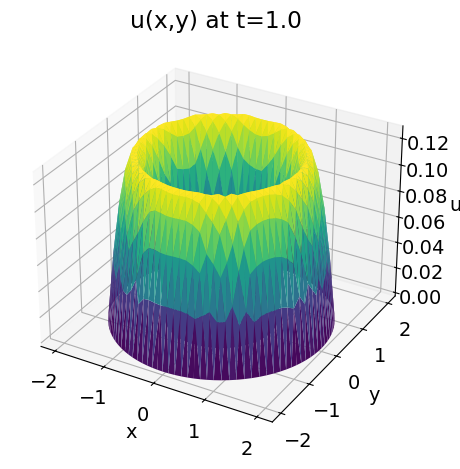

In [12]:
# fig 2: sol at t=1.0
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_trisurf(pts[:,0], pts[:,1], t_save[1.0],triangles=tri, cmap='viridis', linewidth=0.1)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('u')
ax.set_title('u(x,y) at t=1.0')
plt.tight_layout()
plt.show()

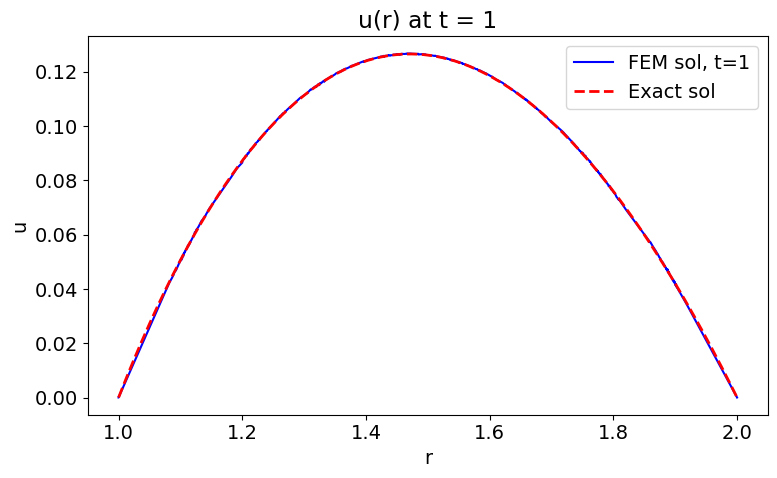

In [14]:
#fig3: exact stationary
u_t1 = t_save[1.0]

[rsort, isort] = np.sort(r_nodes), np.argsort(r_nodes)
usort = u_t1[isort]

r_exact = np.linspace(1,2,400)
u_exact = (1 - r_exact**2)/4.0 + 3*np.log(r_exact)/(4*np.log(2)) # exact sol

plt.figure(figsize=(8, 5))
plt.plot(rsort, usort, 'b-', linewidth=1.5, label='FEM sol, t=1')
plt.plot(r_exact, u_exact, 'r--', linewidth=2, label='Exact sol')
plt.xlabel('r')
plt.ylabel('u')
plt.title('u(r) at t = 1')
plt.legend()
plt.tight_layout()
plt.show()